Multi-fidelity Modeling and Experimental Design (Active Learning)

In [ ]:
# General imports
import numpy as np
np.random.seed(20)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import sys
import os
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()
resum_path = os.getenv("RESUM_PATH")
if resum_path is None:
    raise ValueError("Environment variable RESUM_PATH is not set. Make sure to define it in your .env file.")
utilities_path = os.path.join(resum_path, "utilities")
sys.path.append(utilities_path)
import simulation_utils as sim
import plotting_utils as plotting
import drawing_utils as draw_mfsm
import multi_fidelity_surrogate_model as mfsm
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array
from sklearn.metrics import mean_squared_error

In [ ]:
version = 'v1.6'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'{resum_path}/out/{version}'):
   os.makedirs(f'{resum_path}/out/{version}')
if not os.path.exists(f'{resum_path}/in/Ge77_rates_new_samples_{version}.csv'):
   fout = open(f'{resum_path}/in/Ge77_rates_new_samples_{version}.csv')
   fout.write("#\n ,Sample,Mode,Radius[cm],Thickness[cm],NPanels,Theta[deg],Length[cm],Ge-77[nevents],Ge-77_CNP,Ge-77_CNP_err")
   fout.close()
   

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']
y_label_cnp = 'Ge-77_CNP'
y_err_label_cnp = 'Ge-77_CNP_err'
y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.

# Set a fixed point in space for drawings
x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'{resum_path}/in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)

# Get HF and LF data samples from file

data=pd.read_csv(f'{resum_path}/in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label_cnp,y_err_label_cnp,y_label_sim]]

LF_noise=np.mean(data.loc[data['Mode']==0.][y_err_label_cnp].to_numpy())
HF_noise=np.mean(data.loc[data['Mode']==1.][y_err_label_cnp].to_numpy())

In [3]:

#data.plot(kind='scatter', x=x_labels[2], y=x_labels[3], alpha=0.4, s=data[x_labels[4]]*2, label='Ge-77',
#figsize=(12, 8), c=y_label, cmap=plt.get_cmap('jet'), colorbar=True)
#plt.legend()
#plt.show()

In [4]:

x_train_l, x_train_h, y_train_l, y_train_h = ([],[],[],[])
row_h=data.index[data['Mode'] == 1].tolist()
row_l=data.index[data['Mode'] == 0].tolist()

x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_sim = data.loc[data['Mode']==1.][y_label_sim].to_numpy().tolist()

x_train_hf_cnp = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_cnp = data.loc[data['Mode']==1.][ y_label_cnp].to_numpy().tolist()

x_train_lf_sim = data.loc[data['Mode']==0.][x_labels].to_numpy().tolist()
y_train_lf_sim = data.loc[data['Mode']==0.][ y_label_sim].to_numpy().tolist()

x_train_lf_cnp = data.loc[data['Mode']==0.][x_labels].to_numpy().tolist()
y_train_lf_cnp = data.loc[data['Mode']==0.][ y_label_cnp].to_numpy().tolist()

x_train_lf_cnp, x_train_hf_cnp, x_train_hf_sim, y_train_lf_cnp, y_train_hf_cnp, y_train_hf_sim = (np.atleast_2d(x_train_lf_cnp), np.atleast_2d(x_train_hf_cnp), np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_lf_cnp).T, np.atleast_2d(y_train_hf_cnp).T, np.atleast_2d(y_train_hf_sim).T)



In [5]:
mf_model = mfsm.linear_multi_fidelity_model(x_train_lf_cnp, y_train_lf_cnp, LF_noise, x_train_hf_cnp, y_train_hf_cnp, HF_noise, x_train_hf_sim, y_train_hf_sim, 2)

 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:divide by zero encountered in log


Optimization restart 1/2, f = -288.916416004745


 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/GPy/kern/src/rbf.py:52: RuntimeWarning:overflow encountered in square


Optimization restart 2/2, f = -288.9164159928096


In [6]:
mf_model.gpy_model

gp.,value,constraints,priors
multifidelity.rbf.variance,0.1897422624258478,+ve,
multifidelity.rbf.lengthscale,236.97062780489583,+ve,
multifidelity.rbf_1.variance,5.562684646268137e-309,+ve,
multifidelity.rbf_1.lengthscale,1.0,+ve,
multifidelity.rbf_2.variance,0.0022455843245877956,+ve,
multifidelity.rbf_2.lengthscale,1.0000000197810428,+ve,
multifidelity.rbf_3.variance,1.0,+ve,
multifidelity.rbf_3.lengthscale,1.0,+ve,
multifidelity.scale,"(3,)",,
mixed_noise.Gaussian_noise.variance,0.021286798679867984,+ve fixed,


In [7]:
%%capture
leg_label = []
ncol=1
nrow=int(np.ceil(len(x_labels)/ncol))
fig1,ax1  = plt.subplots(2,3, figsize=(15, 5), constrained_layout=True)
fig2,ax2  = plt.subplots(nrow,ncol, figsize=(5, 12), constrained_layout=True)

In [8]:
add_new_sample=True
sample=0
total_samples=20

Sample # 0


 /var/folders/99/0svbmlns6xs9l9p55lcr912r0000gn/T/ipykernel_39712/439182391.py:12: UserWarning:FigureCanvasAgg is non-interactive, and thus cannot be shown


Sample # 1
Adding LF sample at [183.8, 5.1, 219.0, 49.0, 19.8] with Ge-77_CNP of [0.2846]
Adding HF sample at [183.8, 5.1, 219.0, 49.0, 19.8] with Ge-77_CNP of [0.1634]
Adding HF sample at [183.8, 5.1, 219.0, 49.0, 19.8] with rGe77[nuc/(kg*yr)] of [0.1447]


 /var/folders/99/0svbmlns6xs9l9p55lcr912r0000gn/T/ipykernel_39712/439182391.py:12: UserWarning:FigureCanvasAgg is non-interactive, and thus cannot be shown


Sample # 2
Adding LF sample at [184.2, 5.1, 218.0, 48.9, 17.8] with Ge-77_CNP of [0.2787]
Adding HF sample at [184.2, 5.1, 218.0, 48.9, 17.8] with Ge-77_CNP of [0.1632]
Adding HF sample at [184.2, 5.1, 218.0, 48.9, 17.8] with rGe77[nuc/(kg*yr)] of [0.1671]


...

 /var/folders/99/0svbmlns6xs9l9p55lcr912r0000gn/T/ipykernel_39712/439182391.py:12: UserWarning:FigureCanvasAgg is non-interactive, and thus cannot be shown


Sample # 5
Adding LF sample at [225.2, 9.6, 7.0, 0.0, 3.5] with Ge-77_CNP of [0.1408]
Adding HF sample at [225.2, 9.6, 7.0, 0.0, 3.5] with Ge-77_CNP of [0.1164]
Adding HF sample at [225.2, 9.6, 7.0, 0.0, 3.5] with rGe77[nuc/(kg*yr)] of [0.1778]


 /var/folders/99/0svbmlns6xs9l9p55lcr912r0000gn/T/ipykernel_39712/439182391.py:12: UserWarning:FigureCanvasAgg is non-interactive, and thus cannot be shown


Sample # 6
Adding LF sample at [201.4, 2.6, 317.0, 52.1, 16.6] with Ge-77_CNP of [0.4785]
Adding HF sample at [201.4, 2.6, 317.0, 52.1, 16.6] with Ge-77_CNP of [0.2081]
Adding HF sample at [201.4, 2.6, 317.0, 52.1, 16.6] with rGe77[nuc/(kg*yr)] of [0.1569]


 /var/folders/99/0svbmlns6xs9l9p55lcr912r0000gn/T/ipykernel_39712/439182391.py:12: UserWarning:FigureCanvasAgg is non-interactive, and thus cannot be shown


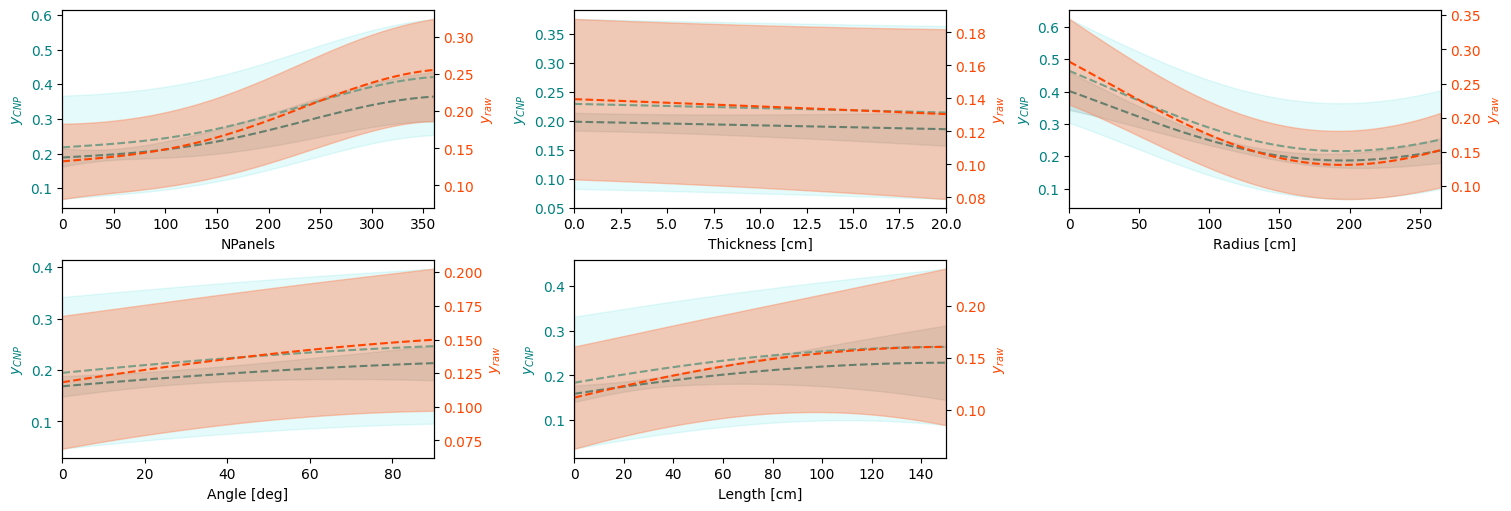

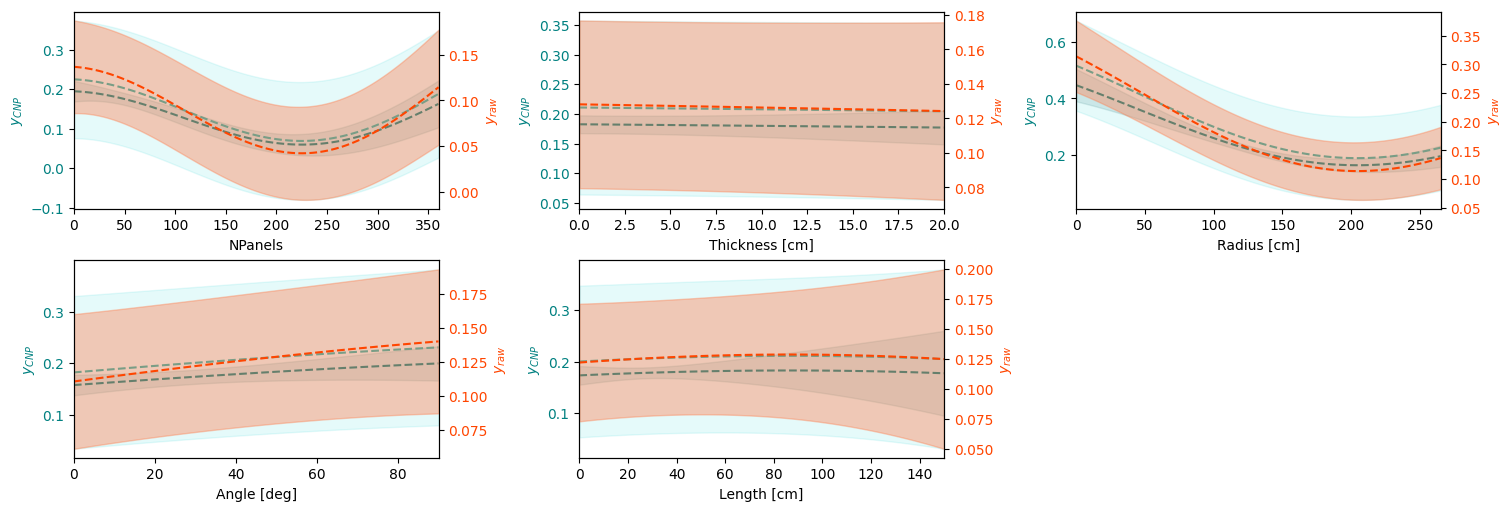

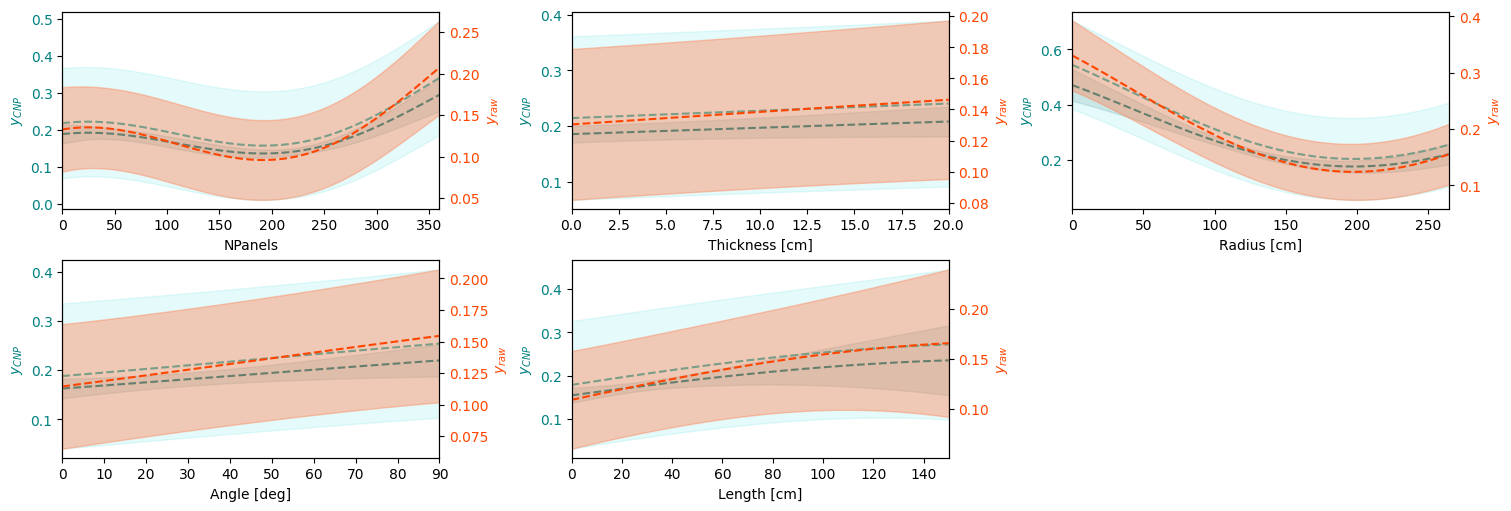

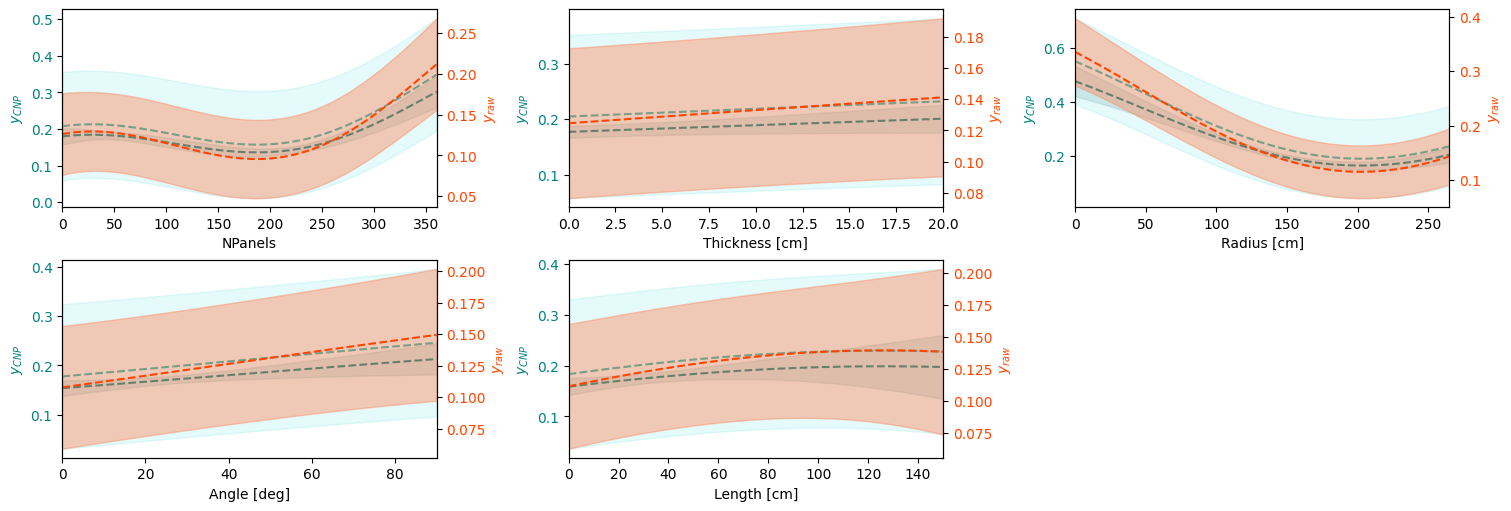

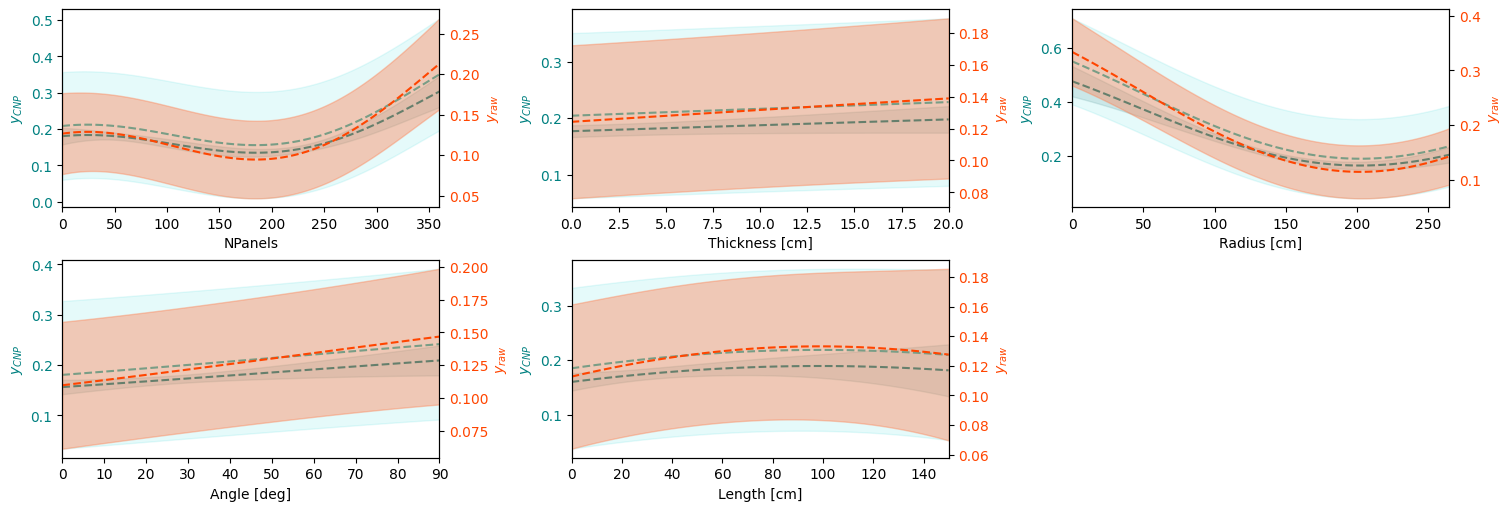

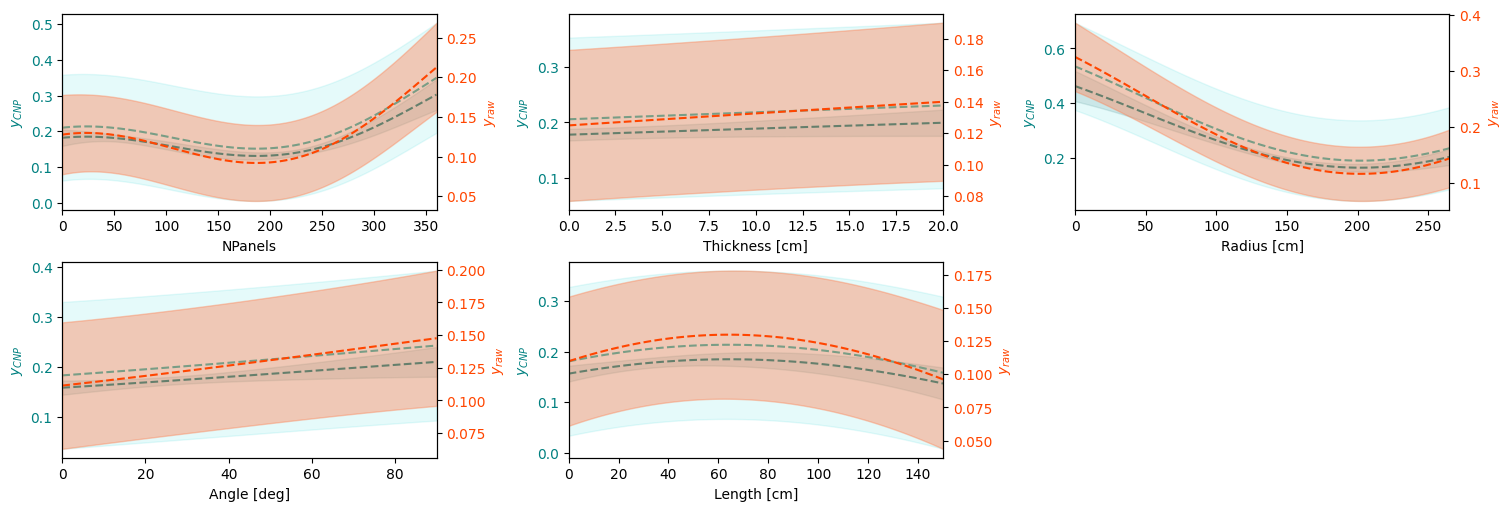

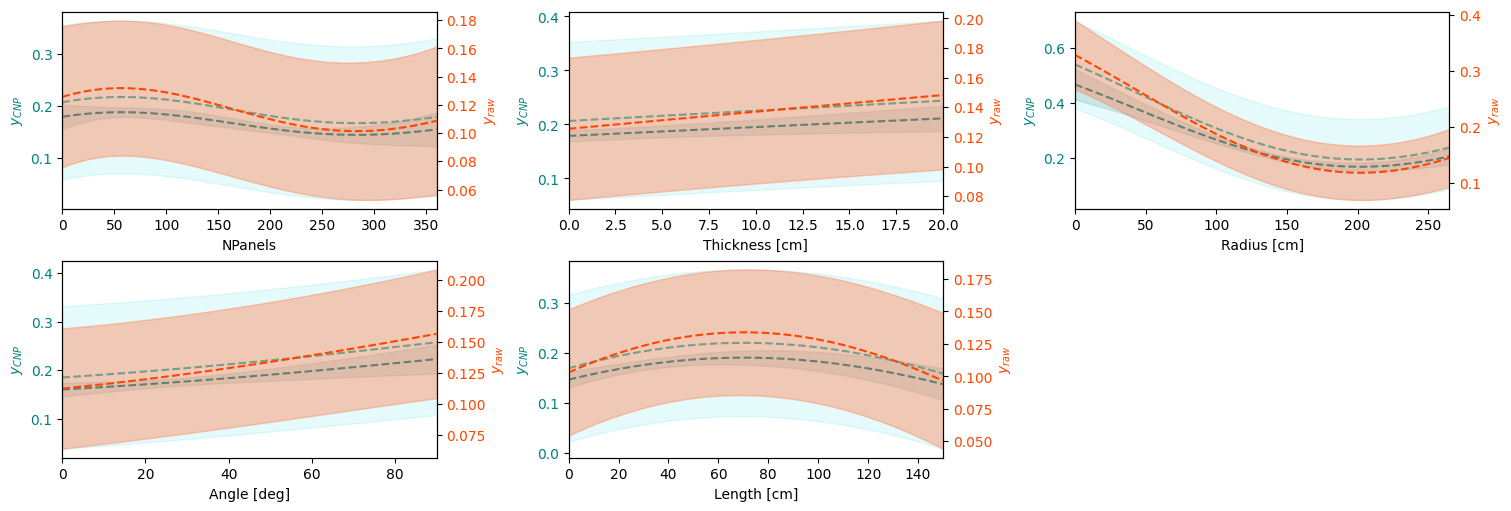

In [9]:

while ( sample < total_samples and sample <= max(mfsm.get_num_new_samples(version)[0],mfsm.get_num_new_samples(version)[1])+1 ):
    print('Sample #', sample)
    # add new data point to training data and update model with new training data
    x_new_data=np.array([])
    y_new_data_h=np.array([])
    if sample > 0:
        x_train_lf_cnp, y_train_lf_cnp, x_train_hf_cnp, y_train_hf_cnp, x_train_hf_sim, y_train_hf_sim, mf_model = mfsm.add_samples(x_train_lf_cnp, y_train_lf_cnp, x_train_hf_cnp, y_train_hf_cnp, x_train_hf_sim, y_train_hf_sim, mf_model, x_labels, [y_label_cnp, y_label_sim] ,sample-1, version)

    # run the model drawing
    draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels_out, factor, version)#
    fig1 = draw_mfsm.draw_model_updated(fig1, mf_model, xmin, xmax, x_labels_out, factor, version, x_fixed=x_fixed)
    fig1.show()
    fig1.savefig("update.png")

    # find the next data point
    #x_next_sample, us_acquisition = mfsm.max_acquisition_integrated_variance_reduction(mf_model, xlow, xhigh, x_labels)
    #print(f'next suggested point to simulated is at: {x_next_sample}')
    #sim.print_geant4_macro(x_next_sample[0],f"n{sample}",mode="LF",version=version)
    #sim.print_geant4_macro(x_next_sample[0],f"n{sample}",mode="HF",version=version)
    #plotting.draw_moderator_config(x_next_sample[0][0],x_next_sample[0][1],x_next_sample[0][2],x_next_sample[0][3],x_next_sample[0][4])
    #fig2 = draw_mfsm.draw_acquisition_func(fig2, us_acquisition, xlow, xhigh, x_labels_out, np.array(x_next_sample), version, x_fixed=x_fixed)
    #xi =x_next_sample[0,:-1]

    sample+=1




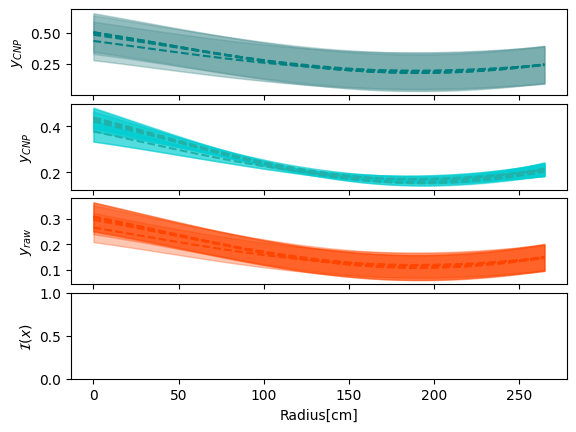

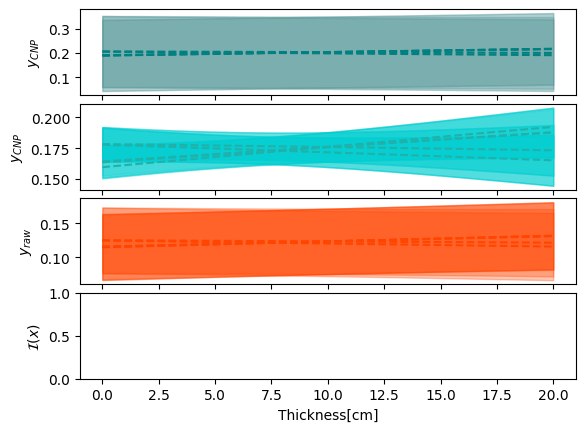

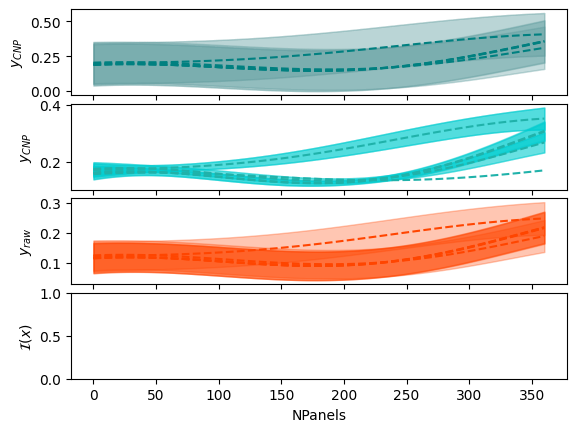

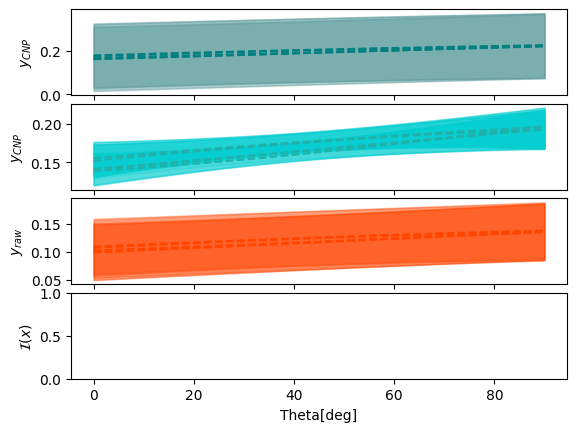

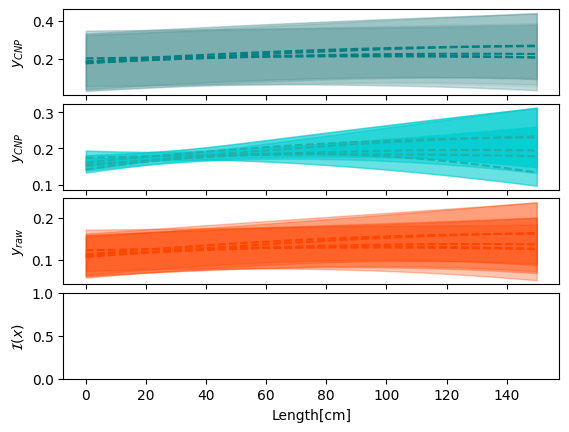

In [10]:
draw_mfsm.draw_model_acquisition_func(fig1,fig2,x_labels,version)

In [ ]:

def model_validation(mf_model, file_in, x_labels, y_label, version):
        data=pd.read_csv(file_in)
        #data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label]]

        x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
        y_train_hf_sim = data.loc[data['Mode']==1.][y_label].to_numpy().tolist()
        x_train_hf_sim, y_train_hf_sim = (np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_hf_sim).T)

        counter_1sigma = 0
        counter_2sigma = 0
        counter_3sigma = 0
        MAE=0
        NMSE=0
        MSSE=0
        mfsm_model_mean = np.empty(shape=[0, 0])
        mfsm_model_std = np.empty(shape=[0, 0])
        hf_data=[]
        x=[]
        for i in range(len(x_train_hf_sim)):

                SPLIT = 1
                x_plot = (np.atleast_2d(x_train_hf_sim[i]))
                X_plot = convert_x_list_to_array([x_plot , x_plot, x_plot])
                hhf_mean_mf_model, hhf_var_mf_model = mf_model.predict(X_plot[2*SPLIT:])
                hhf_std_mf_model = np.sqrt(hhf_var_mf_model)

                hf_data.append(y_train_hf_sim[i])
                x.append(i)
                mfsm_model_mean=np.append(mfsm_model_mean,hhf_mean_mf_model[0,0])
                mfsm_model_std=np.append(mfsm_model_std,hhf_std_mf_model[0,0])
                if (y_train_hf_sim[i] < hhf_mean_mf_model+hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-hhf_std_mf_model):
                        counter_1sigma += 1
                if (y_train_hf_sim[i] < hhf_mean_mf_model+2*hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-2*hhf_std_mf_model):
                        counter_2sigma += 1
                if (y_train_hf_sim[i] < hhf_mean_mf_model+3*hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-3*hhf_std_mf_model):
                        counter_3sigma += 1
                MAE +=np.abs(y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])
                NMSE +=np.abs((y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])/hhf_std_mf_model[0][0])
                MSSE +=pow((y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])/hhf_std_mf_model[0][0],2)

        print("1 sigma: ", counter_1sigma/len(hf_data)*100.," %" )
        print("2 sigma: ", counter_2sigma/len(hf_data)*100.," %" )
        print("3 sigma: ", counter_3sigma/len(hf_data)*100.," %" )

        fig = plt.subplots(figsize=(12, 2.5))
        #plt.bar(x=np.arange(len(mfsm_model_mean)), height=mfsm_model_mean, color="lightgray", label='RESuM')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-3*mfsm_model_std, y2=mfsm_model_mean+3*mfsm_model_std, color="coral",alpha=0.2, label=r'$\pm 3\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-2*mfsm_model_std, y2=mfsm_model_mean+2*mfsm_model_std, color="yellow",alpha=0.2, label=r'$\pm 2\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-mfsm_model_std, y2=mfsm_model_mean+mfsm_model_std, color="green",alpha=0.2, label=r'RESuM $\pm 1\sigma$')
        plt.xlabel('HF Simulation Trial Number')
        plt.ylim(0.,0.55)
        plt.ylabel(r'$y_{raw}$')
        plt.plot(x[:],hf_data[:],'.',color="black", label="HF Validation Data")
        handles, labels = plt.gca().get_legend_handles_labels()
        order = [3,2,1,0]
        plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=9, bbox_to_anchor=(0.665,1.),ncol=5)
        plt.savefig(f'{resum_path}/out/{version}/model-validation_{version}.pdf')
        mse = mean_squared_error(hf_data,mfsm_model_mean, squared=True)
        MAE=MAE/len(x_train_hf_sim)
        NMSE=NMSE/len(x_train_hf_sim)
        MSSE=MSSE/len(x_train_hf_sim)
        print(counter_1sigma/len(hf_data)*100.," & ",counter_2sigma/len(hf_data)*100.," & ",counter_3sigma/len(hf_data)*100.," & ",f"{MAE:.4f}"," & ",f"{NMSE:.4f}"," & ",f"{mse:.4f}"," & ",f"{MSSE:.4f}" ," & \\\ ")
        return fig

In [12]:
while ( sample < total_samples and sample <= max(mfsm.get_num_new_samples(version)[0],mfsm.get_num_new_samples(version)[1])+1 ):
    print('Sample #', sample)
    # add new data point to training data and update model with new training data
    x_new_data=np.array([])
    y_new_data_h=np.array([])
    if sample > 0:
        x_train_lf_cnp, y_train_lf_cnp, x_train_hf_cnp, y_train_hf_cnp, x_train_hf_sim, y_train_hf_sim, mf_model = mfsm.add_samples(x_train_lf_cnp, y_train_lf_cnp, x_train_hf_cnp, y_train_hf_cnp, x_train_hf_sim, y_train_hf_sim, mf_model, x_labels, [y_label_cnp, y_label_sim] ,sample-1, version)

    # run the model drawing
    draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels_out, factor, version)#
    fig1 = draw_mfsm.draw_model_updated(fig1, mf_model, xmin, xmax, x_labels_out, factor, version, x_fixed=x_fixed)
    fig1.show()
    fig1.savefig("update.png")

    # find the next data point
    x_next_sample, us_acquisition = mfsm.max_acquisition_integrated_variance_reduction(mf_model, xlow, xhigh, x_labels)
    print(f'next suggested point to simulated is at: {x_next_sample}')
    sim.print_geant4_macro(x_next_sample[0],f"n{sample}",mode="LF",version=version)
    sim.print_geant4_macro(x_next_sample[0],f"n{sample}",mode="HF",version=version)
    plotting.draw_moderator_config(x_next_sample[0][0],x_next_sample[0][1],x_next_sample[0][2],x_next_sample[0][3],x_next_sample[0][4])
    fig2 = draw_mfsm.draw_acquisition_func(fig2, us_acquisition, xlow, xhigh, x_labels_out, np.array(x_next_sample), version, x_fixed=x_fixed)
    xi =x_next_sample[0,:-1]

    sample+=1
    sample+=1

1 sigma:  69.0  %
2 sigma:  95.0  %
3 sigma:  100.0  %
69.0  &  95.0  &  100.0  &  0.0387  &  0.7880  &  0.0024  &  0.9882  & \\ 


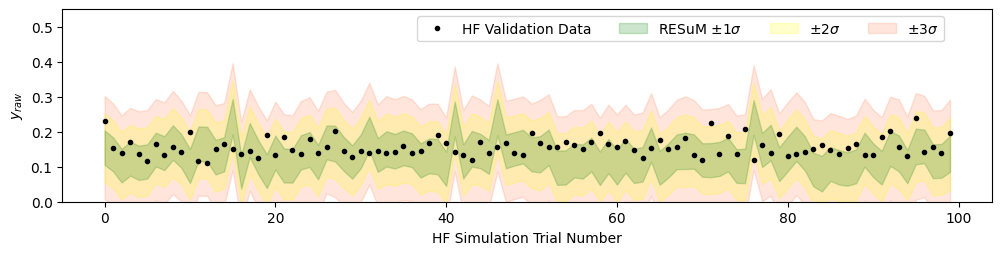

In [13]:
fig = model_validation(mf_model,"in/hf_validation_data_v1.2.csv",x_labels, y_label_sim, version)
plt.show()


In [14]:
x_fmin = [150,10,360,0,3]
f_min = 1.
dx_fmin=[]
dy_fmin=[]
dsigma_fmin=[]
for i in range(50):
    x_fmin_tmp, f_min_tmp = mfsm.get_min_constrained(mf_model, xlow, xhigh, x_labels)
    #plotting.draw_moderator_configuration(x_fmin_tmp)
    dx_fmin.append(x_fmin_tmp)
    dy_fmin.append(f_min_tmp)
    dsigma_fmin.append(mfsm.evaluate_model_uncertainty(x_fmin_tmp,mf_model,2))
    print(f"minimum found at {x_fmin_tmp} with f = {f_min_tmp} {mfsm.evaluate_model(x_fmin_tmp,mf_model,2)} +- {mfsm.evaluate_model_uncertainty(x_fmin_tmp,mf_model,2)} and a reduction of {mfsm.evaluate_model([0.,0.,0.,0.,0.],mf_model,2)/f_min_tmp}")

    if f_min_tmp <= f_min:
        x_fmin = x_fmin_tmp
        f_min = f_min_tmp

    itmp=201+i
    sim.print_geant4_macro(x_fmin_tmp,f"{itmp}",mode="LF",version=f"{version}")


print(f"minimum found at {x_fmin} with f = {f_min} and a reduction of {mfsm.evaluate_model([0.,0.,0.,0.,0.], mf_model,2)/f_min}")
print("high fidelity", mfsm.evaluate_model(x_fmin, mf_model,2), mfsm.evaluate_model([x_fmin[0],plotting.get_outer_radius(x_fmin)-plotting.get_inner_radius(x_fmin),360,0.,4.],mf_model,2))
print("medium fidelity", mfsm.evaluate_model(x_fmin, mf_model,1), mfsm.evaluate_model([x_fmin[0],plotting.get_outer_radius(x_fmin)-plotting.get_inner_radius(x_fmin),360,0.,10.],mf_model,1))
plotting.draw_moderator_configuration(x_fmin)


minimum found at [196.08684570935623, 2.0854857291358537, 168.4407663480513, 12.594984439671922, 13.256336989368812] with f = 0.08045930694147813 0.08045930694147813 +- 0.0486346869228742 and a reduction of 2.958018764870042
minimum found at [196.8814882400522, 4.009514357775052, 131.60106678511102, 3.4819289394312705, 6.057160534007144] with f = 0.07859717515629974 0.07859717515629974 +- 0.04917545283766539 and a reduction of 3.028100428139299
minimum found at [246.17879681784282, 7.495058438585041, 5.044111023677379, 2.782395611518794, 80.26461373584678] with f = 0.08631214244213017 0.08631214244213017 +- 0.04984141977829237 and a reduction of 2.7574351998144757
minimum found at [136.538206497492, 4.110246282093843, 245.26892487705533, 27.289465753115223, 3.089319198312127] with f = 0.09197741522691794 0.09197741522691794 +- 0.048799009943966666 and a reduction of 2.587593260303732
minimum found at [178.3324287892346, 4.148077590654429, 178.8941351666008, 24.076906817900234, 7.449842

KeyboardInterrupt: 